# Setup
import, model definition, helper function

In [1]:
## import libraries
import numpy as np
import torch
import nltk
import re, pprint

from sentence_transformers import SentenceTransformer
from IPython.display import display, Latex
from deepmultilingualpunctuation import PunctuationModel

In [2]:
## Define models used in this notebook
punctuation_restoration = PunctuationModel() # model for punctuation restoration https://huggingface.co/oliverguhr/fullstop-punctuation-multilang-large
sentence_transformer = SentenceTransformer('all-MiniLM-L6-v2') # sentence transformer model

Device set to use mps:0
/opt/homebrew/anaconda3/envs/RAG/lib/python3.12/site-packages/transformers/pipelines/token_classification.py:170: UserWarning: `grouped_entities` is deprecated and will be removed in version v5.0.0, defaulted to `aggregation_strategy="AggregationStrategy.NONE"` instead.
  warnings.warn(


In [3]:
## Download nltk data
nltk.download('all')

[nltk_data] Downloading collection 'all'
[nltk_data]    | 
[nltk_data]    | Downloading package abc to /Users/964505/nltk_data...
[nltk_data]    |   Package abc is already up-to-date!
[nltk_data]    | Downloading package alpino to
[nltk_data]    |     /Users/964505/nltk_data...
[nltk_data]    |   Package alpino is already up-to-date!
[nltk_data]    | Downloading package averaged_perceptron_tagger to
[nltk_data]    |     /Users/964505/nltk_data...
[nltk_data]    |   Package averaged_perceptron_tagger is already up-
[nltk_data]    |       to-date!
[nltk_data]    | Downloading package averaged_perceptron_tagger_eng to
[nltk_data]    |     /Users/964505/nltk_data...
[nltk_data]    |   Package averaged_perceptron_tagger_eng is already
[nltk_data]    |       up-to-date!
[nltk_data]    | Downloading package averaged_perceptron_tagger_ru to
[nltk_data]    |     /Users/964505/nltk_data...
[nltk_data]    |   Package averaged_perceptron_tagger_ru is already
[nltk_data]    |       up-to-date!
[nlt

True

## Helper functions

In [4]:
## Filter filler words from transcripts
def filter_filler_words(text):
    filler_words = ["um", "uh", "like", "you know", "so", "actually"]
    words = text.split()
    filtered_text = " ".join([word for word in words if word.lower() not in filler_words])
    return filtered_text

# Load transcript

In [5]:
## Read lecture transcript
with open("transcripts/lecture-1.txt", "r") as file:
    transcript = file.read()

In [6]:
## Display the original transcript's first 100 characters
display(Latex(transcript[:100]))

<IPython.core.display.Latex object>

# Remove Filler Words

In [7]:
## remove fillter words
filtered_transcript = filter_filler_words(transcript)

In [8]:
## print length of filtered transcripts and original transcripts to compare, original should be longer
print(f"Original Transcript Length: {len(transcript)}")
print(f"Filtered Transcript Length: {len(filtered_transcript)}")

Original Transcript Length: 41277
Filtered Transcript Length: 39575


In [9]:
## Display the filtered transcript's first 100 characters
display(Latex(filtered_transcript[:200]))

<IPython.core.display.Latex object>

# Add punctuation for easier sentence fragmentation

In [10]:
punctuated_transcript = punctuation_restoration.restore_punctuation(filtered_transcript)

In [11]:
punctuated_transcript

"we are going to post these lecture videos online. I think n has sent an email to you. if you have any issues or concerns, or please let us know. but this is lecture number one. let's get started. I am sharing my iPad window. hopefully you can see my screen as I start writing. this is lecture one and today I will be talking about, you know, one of the first, very first topics in machine learning, which is linear regression. as an example of a problem, right, let's consider an example, predictive problem, which is: let's suppose you want to predict levels of some particular BSA levels from various measurements, measurements on the prostate. okay, you know, it's not the, the details are not that important, but what is important is that there are two things. one is that there are are some measurements on something that we want to do, prediction on those we will represent by the XI. we'll typically have training data, which will be X1, X2, X3, X4 and on till X, end, and along with every tr

# Chunking

In [12]:
## segment the text into sentences
sentences = nltk.sent_tokenize(punctuated_transcript)
sentences[:5] # print the first 5 sentences

['we are going to post these lecture videos online.',
 'I think n has sent an email to you.',
 'if you have any issues or concerns, or please let us know.',
 'but this is lecture number one.',
 "let's get started."]

In [13]:
## define grammar and regex parser for chunking
gram = ("NP: {<DT>?<JJ>*<NN>}") #TODO: Understand what grammar is and how to define it
chunking = nltk.RegexpParser(gram)

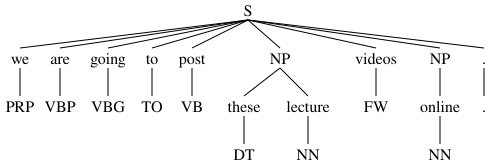

Bad pipe message: %s [b'Vz\xe1d*\xcc\xcfu\x9fXl\xb5\x0e\xad\xf4uZ:\x00\x01|\x00\x00\x00\x01\x00\x02\x00\x03\x00\x04\x00\x05\x00\x06\x00\x07\x00\x08\x00\t\x00\n\x00\x0b\x00\x0c\x00\r\x00\x0e\x00\x0f\x00\x10\x00\x11\x00\x12\x00\x13\x00\x14\x00\x15\x00\x16\x00\x17\x00\x18\x00\x19\x00\x1a\x00\x1b\x00/\x000\x001\x002\x003\x004\x005']
Bad pipe message: %s [b'\x83\xde\xfe<\x1e', b'\xbdJ\xd2\x86\xb42z\xcf\xfd\xba\xad\x00\x01|\x00\x00\x00\x01\x00\x02\x00\x03\x00\x04\x00\x05\x00\x06\x00\x07\x00\x08\x00\t\x00\n\x00\x0b\x00\x0c\x00\r\x00\x0e\x00\x0f\x00\x10\x00\x11\x00\x12\x00\x13\x00\x14\x00\x15\x00\x16\x00\x17\x00\x18\x00\x19\x00\x1a\x00\x1b\x00/\x000\x001\x002\x003\x004\x005\x006\x007\x008\x009\x00:\x00;\x00<\x00=\x00>\x00?\x00@\x00A\x00B\x00C\x00D\x00E\x00F\x00g\x00h\x00i\x00j\x00k\x00l\x00m\x00\x84\x00\x85\x00\x86\x00\x87\x00\x88\x00\x89\x00\x96\x00\x97\x00\x98\x00\x99\x00\x9a\x00\x9b\x00\x9c\x00\x9d\x00\x9e\x00\x9f\x00\xa0\x00\xa1\x00\xa2\x00\xa3\x00\xa4\x00\xa5\x00']
Bad pipe message: %s [b

In [14]:
## loop through sentences and apply chunking
for sentence in sentences:
    # tokenize the sentence
    tokens = nltk.word_tokenize(sentence)
    # tag the tokens with part-of-speech
    tagged_tokens = nltk.pos_tag(tokens)
    # apply chunking
    tree = chunking.parse(tagged_tokens)
    # debug, comment out or remove later
    display(tree)
    break

# Save final results